# <center>Le Théorème Central Limite (TCL)</center>

## 1. Concept
**Principe général :** Le théorème explique l'émergence de l'ordre (Loi Normale) à partir du chaos (distributions quelconques) via l'opération de moyenne.

* **Observation initiale :** Une variable aléatoire isolée (ex: un lancer de dé) suit sa propre distribution, souvent irrégulière ou uniforme.
* **Le mécanisme :** Si l'on constitue des échantillons de taille $n$ et que l'on calcule leur **moyenne**, la distribution de ces moyennes change de forme.
* **Convergence :** À mesure que $n$ augmente (généralement $n \geq 30$), la distribution des moyennes converge systématiquement vers une **courbe en cloche (Gaussienne)**.

**Point clé :** Ce résultat est valide quelle que soit la forme de la distribution d'origine (uniforme, exponentielle, etc.), pourvu que les variables soient indépendantes. Cela explique l'omniprésence de la loi normale dans les phénomènes naturels (résultant d'une somme de causes indépendantes).

## 2. Repères Historiques
L'élaboration du théorème s'est faite en trois étapes majeures :
* **Abraham de Moivre (1733) :** Première identification du phénomène dans le cas particulier de la loi binomiale (jeux de pile ou face).
* **Pierre-Simon de Laplace (1812) :** Généralisation du concept. Il démontre que cette approximation ne se limite pas aux lois binomiales mais s'étend à d'autres distributions.
* **Alexandre Liapounov (1901) :** Formalisation de la démonstration rigoureuse moderne (théorie des fonctions caractéristiques).

## 3. Formulation Mathématique
**Hypothèses de départ :**
Soit $X_1, X_2, \dots, X_n$ une suite de variables aléatoires :
1.  Indépendantes et identiquement distribuées (i.i.d).
2.  D'espérance $\mu$ et d'écart-type $\sigma$ (variance finie).

**Définition :**
Soit $\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$ la moyenne empirique de l'échantillon.

Quand $n \to \infty$, la variable centrée réduite converge en loi vers la loi normale standard $\mathcal{N}(0, 1)$ :

$$
Z_n = \frac{\bar{X}_n - \mu}{\frac{\sigma}{\sqrt{n}}} = \sqrt{n} \left( \frac{\bar{X}_n - \mu}{\sigma} \right) \xrightarrow{d} \mathcal{N}(0, 1)
$$

**Approximation pratique :**
Pour $n$ suffisamment grand, la moyenne empirique suit approximativement :
$$
\bar{X}_n \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

In [1]:
%pip install numpy pandas matplotlib scipy ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 28.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 52.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 51.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 56.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 48.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [ipywidgets]3 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import ipywidgets as widgets
from IPython.display import display

# Configuration pour un affichage propre
%matplotlib inline
plt.style.use('ggplot')

In [6]:
def visualize_clt(n_samples=30, n_simulations=1000, distribution='Uniforme'):
    """
    n_samples : nombre d'observations par échantillon (le 'n' du théorème)
    n_simulations : nombre de fois qu'on répète l'expérience pour construire l'histogramme
    distribution : la forme de la distribution d'origine
    """
    plt.figure(figsize=(14, 7))
    
    # 1. Génération des données selon la distribution choisie (Le Chaos d'origine)
    # On génère une matrice (n_simulations x n_samples)
    
    if distribution == 'Uniforme':
        # Loi uniforme entre 0 et 1 (Moyenne = 0.5, Variance = 1/12)
        data = np.random.uniform(0, 1, (n_simulations, n_samples))
        mu_theorique = 0.5
        sigma_theorique = np.sqrt(1/12)
        color = 'skyblue'
        
    elif distribution == 'Exponentielle':
        # Loi exponentielle avec lambda=1 (Moyenne = 1, Variance = 1)
        data = np.random.exponential(1, (n_simulations, n_samples))
        mu_theorique = 1.0
        sigma_theorique = 1.0
        color = 'lightgreen'
        
    elif distribution == 'Bernoulli (Pile/Face)':
        # Loi de Bernoulli p=0.5 (Moyenne = 0.5, Variance = 0.25)
        data = np.random.binomial(1, 0.5, (n_simulations, n_samples))
        mu_theorique = 0.5
        sigma_theorique = 0.5 # sqrt(p(1-p))
        color = 'salmon'

    # 2. Calcul des moyennes (La transformation)
    # On calcule la moyenne de chaque ligne (chaque simulation)
    sample_means = np.mean(data, axis=1)
    
    # 3. Affichage de l'histogramme des moyennes
    count, bins, ignored = plt.hist(sample_means, bins=50, density=True, 
                                    alpha=0.7, color=color, edgecolor='white', label='Distribution des moyennes')
    
    # 4. Affichage de la courbe Normale Théorique (La Prédiction du TCL)
    # Le TCL dit que l'écart-type de la moyenne est sigma / sqrt(n)
    sigma_mean = sigma_theorique / np.sqrt(n_samples)
    
    # Génération de la courbe en cloche
    x = np.linspace(min(bins), max(bins), 100)
    pdf = stats.norm.pdf(x, mu_theorique, sigma_mean)
    
    plt.plot(x, pdf, color='red', linewidth=3, label=f'Loi Normale Théorique\n$\mu={mu_theorique}, \sigma={sigma_mean:.3f}$')
    
    # Mise en forme
    plt.title(f"Théorème Central Limite en action (n={n_samples})", fontsize=16)
    plt.xlabel("Valeur de la moyenne", fontsize=12)
    plt.ylabel("Fréquence", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Création des widgets interactifs comme dans votre exemple gbm
ui = widgets.interactive(
    visualize_clt, 
    n_samples=widgets.IntSlider(min=1, max=20, step=1, value=1, description='Taille n'),
    n_simulations=widgets.IntSlider(min=100, max=1000, step=100, value=2000, description='Simulations'),
    distribution=widgets.Dropdown(options=['Uniforme', 'Exponentielle', 'Bernoulli (Pile/Face)'], value='Uniforme', description='Loi Mère')
)

display(ui)


<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/var/folders/5c/3wm53hmx0gzdyzvnjz859hg40000gn/T/ipykernel_72162/50903039.py:49: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, pdf, color='red', linewidth=3, label=f'Loi Normale Théorique\n$\mu={mu_theorique}, \sigma={sigma_mean:.3f}$')
/var/folders/5c/3wm53hmx0gzdyzvnjz859hg40000gn/T/ipykernel_72162/50903039.py:49: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, pdf, color='red', linewidth=3, label=f'Loi Normale Théorique\n$\mu={mu_theorique}, \sigma={sigma_mean:.3f}$')


interactive(children=(IntSlider(value=1, description='Taille n', max=20, min=1), IntSlider(value=1000, descrip…

In [2]:
print("Hello")

Hello


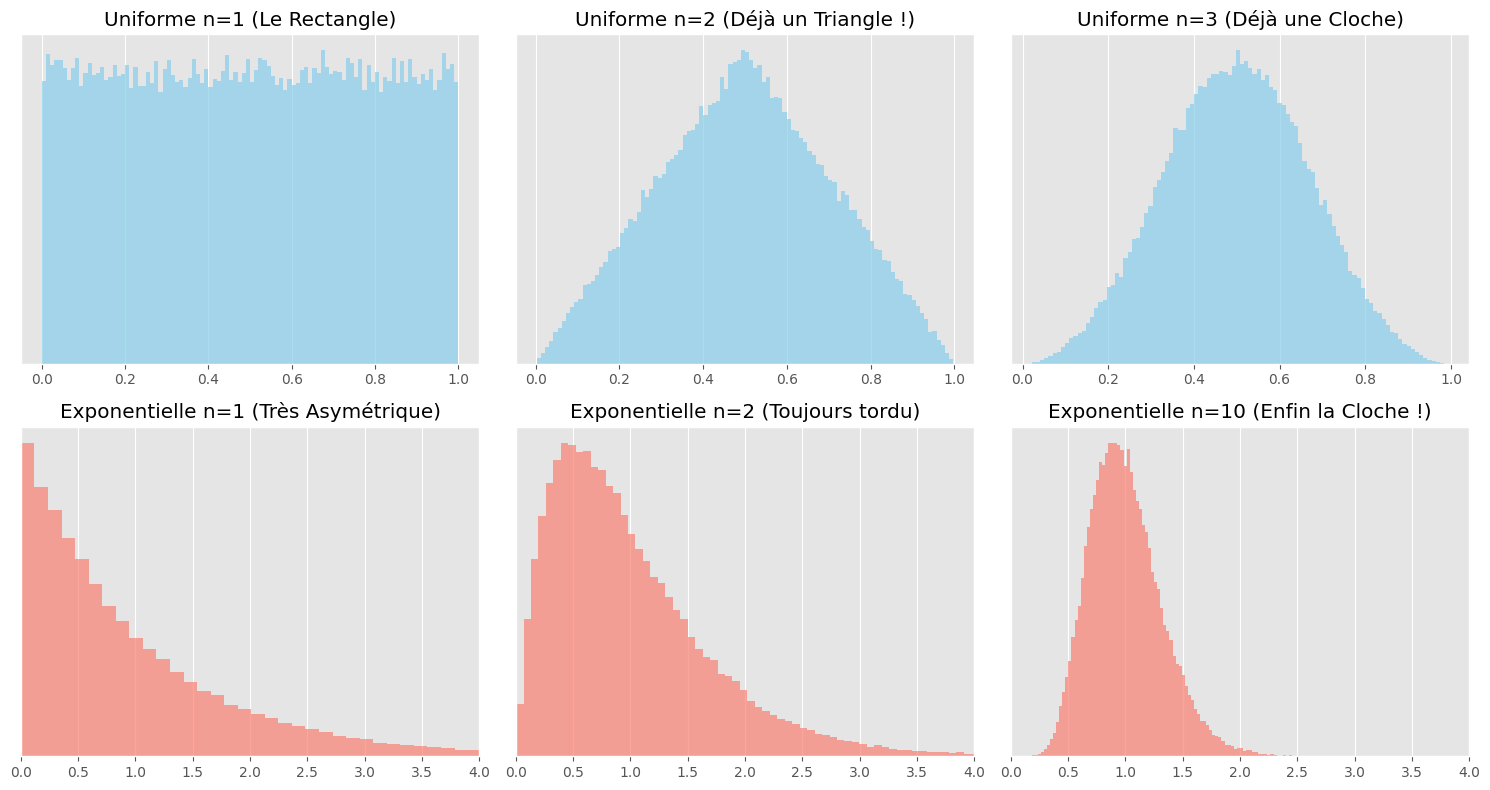

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration
n_simulations = 100000
bins = 100

plt.figure(figsize=(15, 8))

# --- CAS 1 : LOI UNIFORME (Le Sprinteur) ---
# n = 1 (Rectangle)
plt.subplot(2, 3, 1)
data_u1 = np.mean(np.random.uniform(0, 1, (n_simulations, 1)), axis=1)
plt.hist(data_u1, bins=bins, density=True, color='skyblue', alpha=0.7)
plt.title("Uniforme n=1 (Le Rectangle)")
plt.yticks([])

# n = 2 (Le Triangle)
plt.subplot(2, 3, 2)
data_u2 = np.mean(np.random.uniform(0, 1, (n_simulations, 2)), axis=1)
plt.hist(data_u2, bins=bins, density=True, color='skyblue', alpha=0.7)
plt.title("Uniforme n=2 (Déjà un Triangle !)")
plt.yticks([])

# n = 3 (Quasi-Gaussienne)
plt.subplot(2, 3, 3)
data_u3 = np.mean(np.random.uniform(0, 1, (n_simulations, 3)), axis=1)
plt.hist(data_u3, bins=bins, density=True, color='skyblue', alpha=0.7)
plt.title("Uniforme n=3 (Déjà une Cloche)")
plt.yticks([])

# --- CAS 2 : LOI EXPONENTIELLE (Le Diesel) ---
# n = 1 (La Rampe)
plt.subplot(2, 3, 4)
data_e1 = np.mean(np.random.exponential(1, (n_simulations, 1)), axis=1)
plt.hist(data_e1, bins=bins, density=True, color='salmon', alpha=0.7)
plt.title("Exponentielle n=1 (Très Asymétrique)")
plt.xlim(0, 4)
plt.yticks([])

# n = 2 (Encore tordu)
plt.subplot(2, 3, 5)
data_e2 = np.mean(np.random.exponential(1, (n_simulations, 2)), axis=1)
plt.hist(data_e2, bins=bins, density=True, color='salmon', alpha=0.7)
plt.title("Exponentielle n=2 (Toujours tordu)")
plt.xlim(0, 4)
plt.yticks([])

# n = 10 (Enfin ça ressemble à quelque chose)
plt.subplot(2, 3, 6)
data_e10 = np.mean(np.random.exponential(1, (n_simulations, 10)), axis=1)
plt.hist(data_e10, bins=bins, density=True, color='salmon', alpha=0.7)
plt.title("Exponentielle n=10 (Enfin la Cloche !)")
plt.xlim(0, 4)
plt.yticks([])

plt.tight_layout()
plt.savefig('convergence_comparison.png')
